In [1]:
# ── Config & Imports ──────────────────────────────────────────────────────────
import json, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Point at a directory of *_GameMetrics.jsonl files, or a single file.
METRICS_PATH = Path('games/BasePersonality')
AGENT_POWER  = 'ITALY'

WIN_THRESHOLD = 18
ALL_POWERS    = ['AUSTRIA', 'ENGLAND', 'FRANCE', 'GERMANY', 'ITALY', 'RUSSIA', 'TURKEY']
REL_SCORE     = {'Enemy': -2, 'Unfriendly': -1, 'Neutral': 0, 'Friendly': 1, 'Ally': 2}
POWER_COLORS  = dict(zip(ALL_POWERS, plt.cm.tab10.colors))

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})


In [2]:
# ── Load Files & Helpers ──────────────────────────────────────────────────────
if METRICS_PATH.is_file():
    jsonl_files = [METRICS_PATH]
else:
    jsonl_files = sorted(METRICS_PATH.glob('*_GameMetrics.jsonl'))

print(f"Found {len(jsonl_files)} game file(s):")
for f in jsonl_files:
    print(f"  {f.name}")

def load_events(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

_SEASON = {'SPRING': 0, 'FALL': 1, 'WINTER': 2}
_PTYPE  = {'MOVEMENT': 0, 'RETREATS': 1, 'ADJUSTMENTS': 2}

def phase_key(name: str) -> tuple:
    parts = name.split()
    return (int(parts[1]), _SEASON.get(parts[0], 3), _PTYPE.get(parts[2], 3))

def classify_order(order: str) -> str:
    s = order.strip().upper()
    if re.search(r'\bS\b', s) and '-' in s: return 'support_move'
    if re.search(r'\bS\b', s):               return 'support_hold'
    if re.search(r'\bC\b', s) and '-' in s: return 'convoy'
    if '-' in s:                               return 'move'
    if re.search(r'\bH\b', s):               return 'hold'
    if s.startswith('B '):                     return 'build'
    if s.startswith('D '):                     return 'disband'
    return 'other'

# Load all games into a list of event lists
all_games = [(f.stem, load_events(f)) for f in jsonl_files]
print(f"\nTotal events across all games: {sum(len(e) for _, e in all_games)}")


Found 3 game file(s):
  Game1_GameMetrics.jsonl
  Game2_GameMetrics.jsonl
  Game3_GameMetrics.jsonl

Total events across all games: 2990


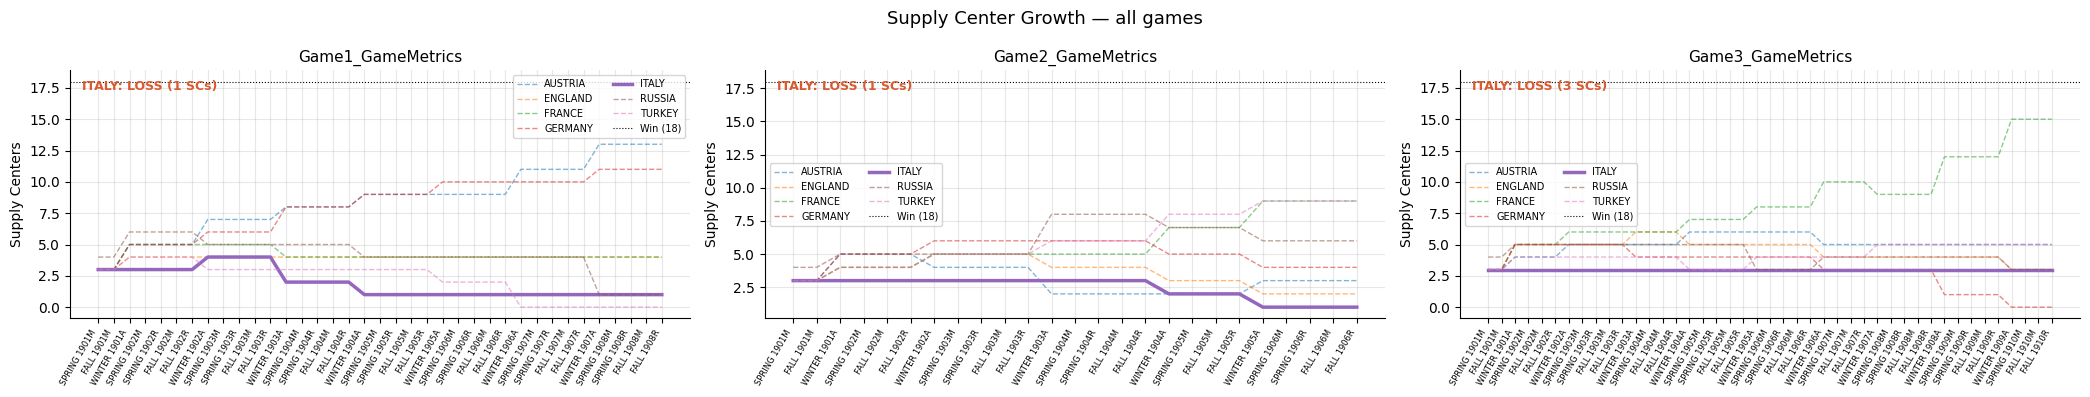

In [3]:
# ── Supply Center Growth ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(all_games), figsize=(7 * len(all_games), 4), squeeze=False)

for ax, (name, events) in zip(axes[0], all_games):
    sc_events = sorted(
        [e for e in events if e['event'] == 'sc_snapshot'],
        key=lambda e: phase_key(e['phase'])
    )
    if not sc_events:
        ax.set_title(f'{name} — no SC data'); continue

    phases = [e['phase'] for e in sc_events]
    for power in ALL_POWERS:
        counts = [e['counts'].get(power, 0) for e in sc_events]
        lw = 2.5 if power == AGENT_POWER else 1
        ls = '-'  if power == AGENT_POWER else '--'
        alpha = 1 if power == AGENT_POWER else 0.55
        ax.plot(range(len(phases)), counts, label=power,
                color=POWER_COLORS[power], linewidth=lw, linestyle=ls, alpha=alpha)

    ax.axhline(WIN_THRESHOLD, color='black', linewidth=0.8, linestyle=':', label='Win (18)')
    ax.set_xticks(range(len(phases)))
    ax.set_xticklabels([p.replace(' MOVEMENT','M').replace(' RETREATS','R')
                        .replace(' ADJUSTMENTS','A') for p in phases],
                       rotation=60, ha='right', fontsize=6)
    ax.set_ylabel('Supply Centers')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=7, ncol=2)

    final = sc_events[-1]['counts']
    agent_sc = final.get(AGENT_POWER, 0)
    won = agent_sc >= WIN_THRESHOLD
    ax.text(0.02, 0.96, f"{AGENT_POWER}: {'WIN' if won else 'LOSS'} ({agent_sc} SCs)",
            transform=ax.transAxes, va='top', fontsize=9,
            color='#1D9E75' if won else '#D85A30', fontweight='bold')

fig.suptitle(f'Supply Center Growth — all games', fontsize=13)
plt.tight_layout()
plt.show()


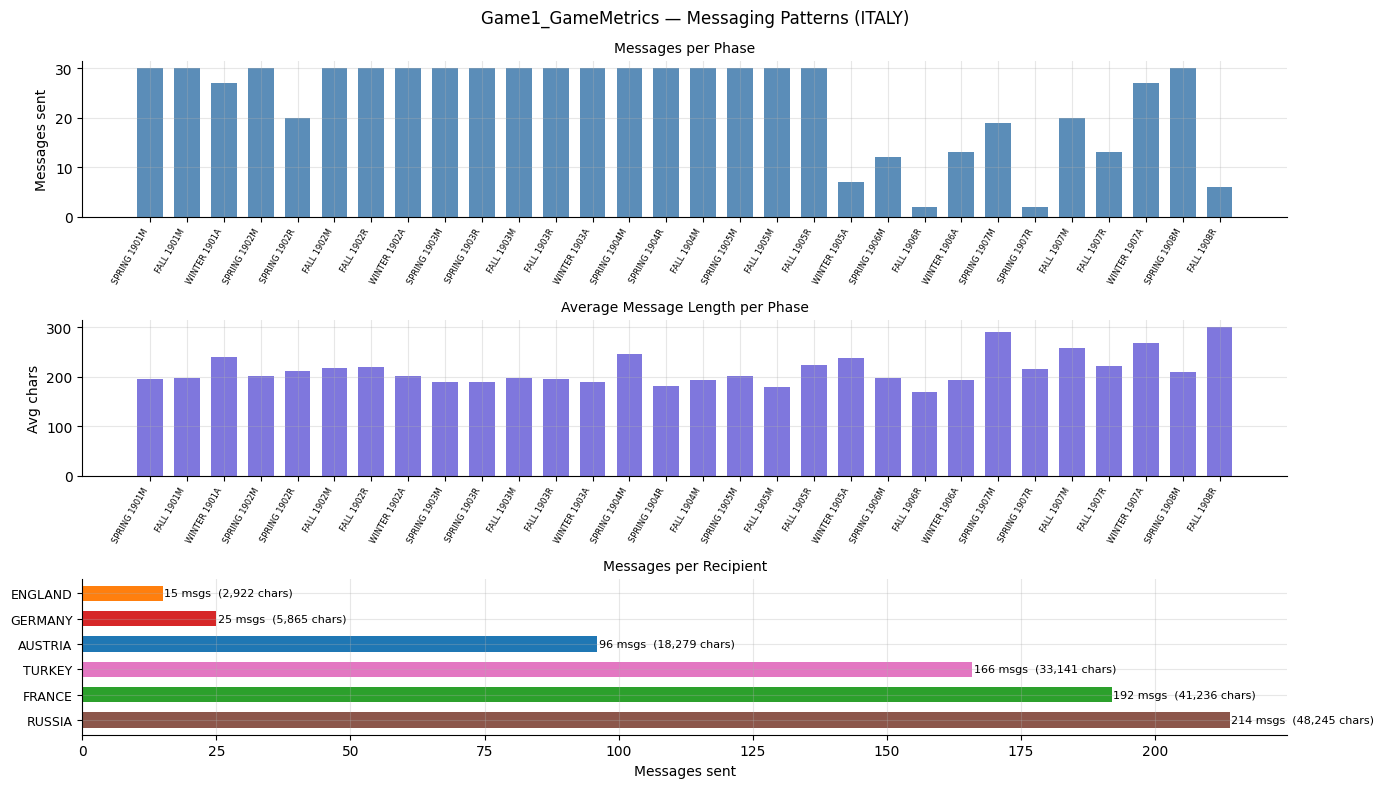

Game1_GameMetrics totals: 708 messages, 149,688 chars, avg 211 chars/msg



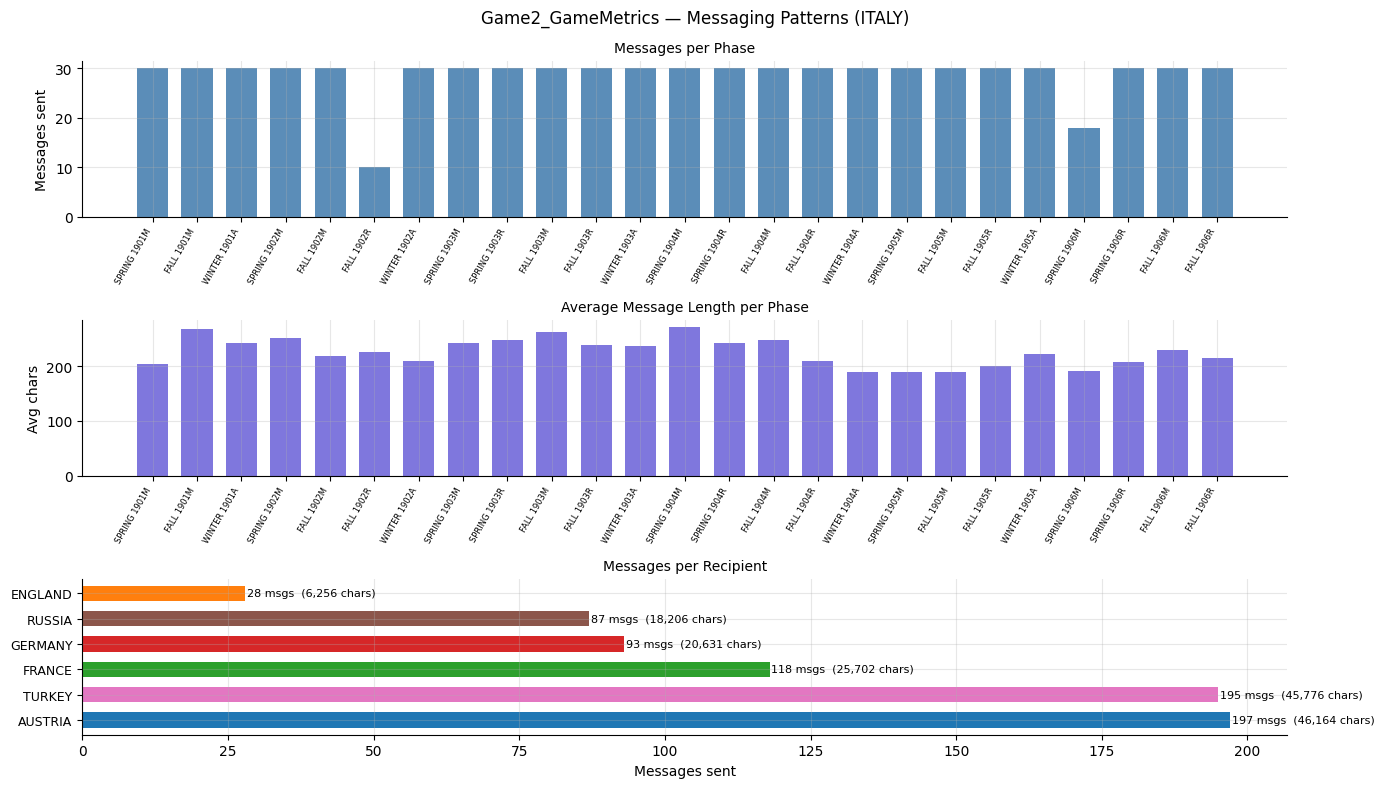

Game2_GameMetrics totals: 718 messages, 162,735 chars, avg 227 chars/msg



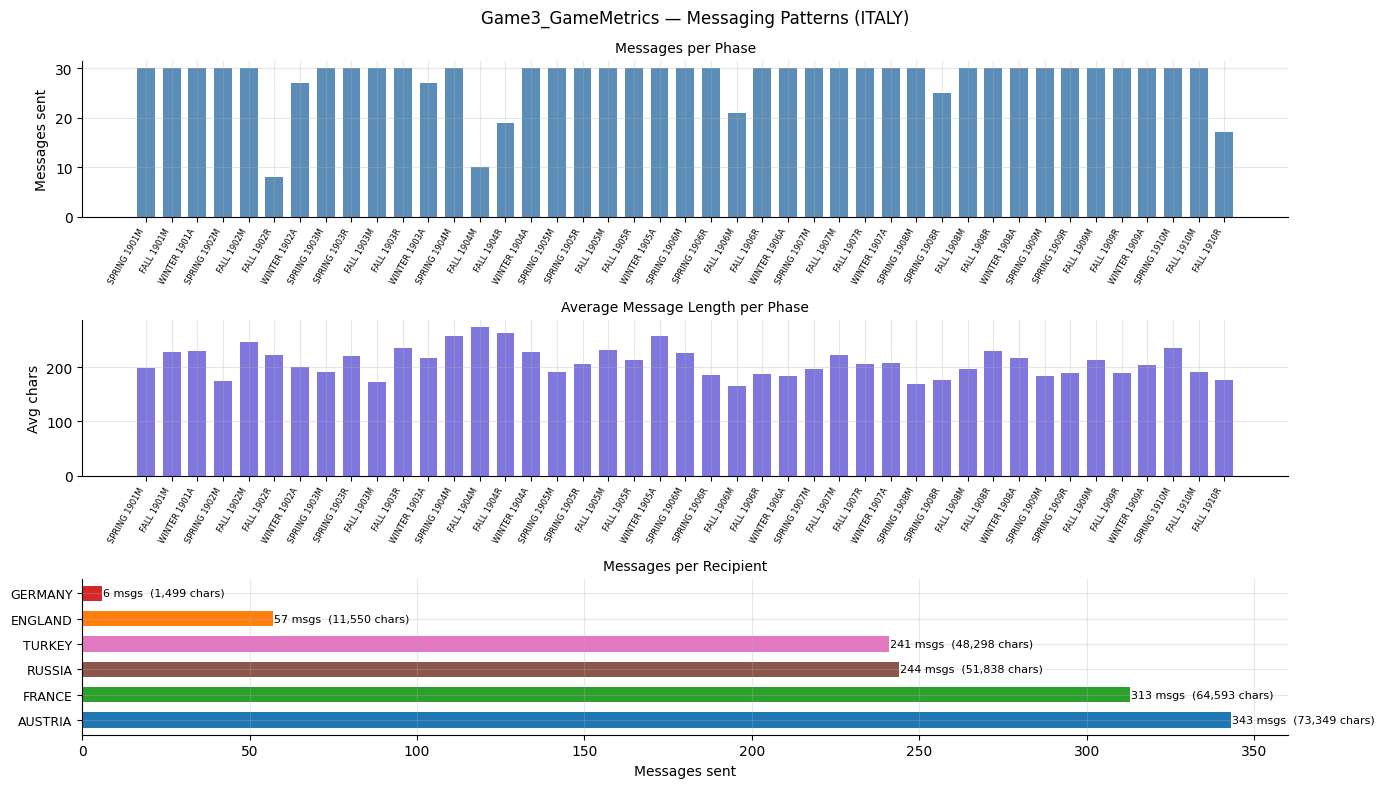

Game3_GameMetrics totals: 1204 messages, 251,127 chars, avg 209 chars/msg



In [4]:
# ── Messaging Patterns ────────────────────────────────────────────────────────
for name, events in all_games:
    msgs = [e for e in events if e['event'] == 'message_sent' and e.get('sender') == AGENT_POWER]
    if not msgs:
        print(f'{name}: no messages from {AGENT_POWER}'); continue

    phases_sorted = sorted({e['phase'] for e in msgs}, key=phase_key)
    by_phase = defaultdict(list)
    for m in msgs:
        by_phase[m['phase']].append(m)

    counts  = [len(by_phase.get(p, [])) for p in phases_sorted]
    avg_len = [np.mean([m['n_chars'] for m in by_phase[p]])
               if by_phase.get(p) else 0 for p in phases_sorted]

    xlabels = [p.replace(' MOVEMENT','M').replace(' RETREATS','R')
                .replace(' ADJUSTMENTS','A') for p in phases_sorted]

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8))
    fig.suptitle(f'{name} — Messaging Patterns ({AGENT_POWER})', fontsize=12)

    # Messages per phase
    ax1.bar(range(len(phases_sorted)), counts, color='#5B8DB8', width=0.7)
    ax1.set_xticks(range(len(phases_sorted)))
    ax1.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=6)
    ax1.set_ylabel('Messages sent')
    ax1.set_title('Messages per Phase', fontsize=10)

    # Avg message length per phase
    ax2.bar(range(len(phases_sorted)), avg_len, color='#7F77DD', width=0.7)
    ax2.set_xticks(range(len(phases_sorted)))
    ax2.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=6)
    ax2.set_ylabel('Avg chars')
    ax2.set_title('Average Message Length per Phase', fontsize=10)

    # Messages per recipient
    rec_counts = defaultdict(int)
    rec_chars  = defaultdict(int)
    for m in msgs:
        rec_counts[m['recipient']] += 1
        rec_chars[m['recipient']]  += m['n_chars']
    recs  = sorted(rec_counts, key=rec_counts.get, reverse=True)
    colors = [POWER_COLORS.get(r, '#888') for r in recs]
    ax3.barh(range(len(recs)), [rec_counts[r] for r in recs], color=colors, height=0.6)
    ax3.set_yticks(range(len(recs)))
    ax3.set_yticklabels(recs, fontsize=9)
    ax3.set_xlabel('Messages sent')
    ax3.set_title('Messages per Recipient', fontsize=10)
    for i, r in enumerate(recs):
        ax3.text(rec_counts[r] + 0.3, i,
                 f"{rec_counts[r]} msgs  ({rec_chars[r]:,} chars)",
                 va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"{name} totals: {len(msgs)} messages, "
          f"{sum(m['n_chars'] for m in msgs):,} chars, "
          f"avg {np.mean([m['n_chars'] for m in msgs]):.0f} chars/msg")
    print()


/tmp/ipykernel_7752/2009156167.py:53: RuntimeWarning: invalid value encountered in divide
  aggr  = np.where(total > 0, moves / total, 0)


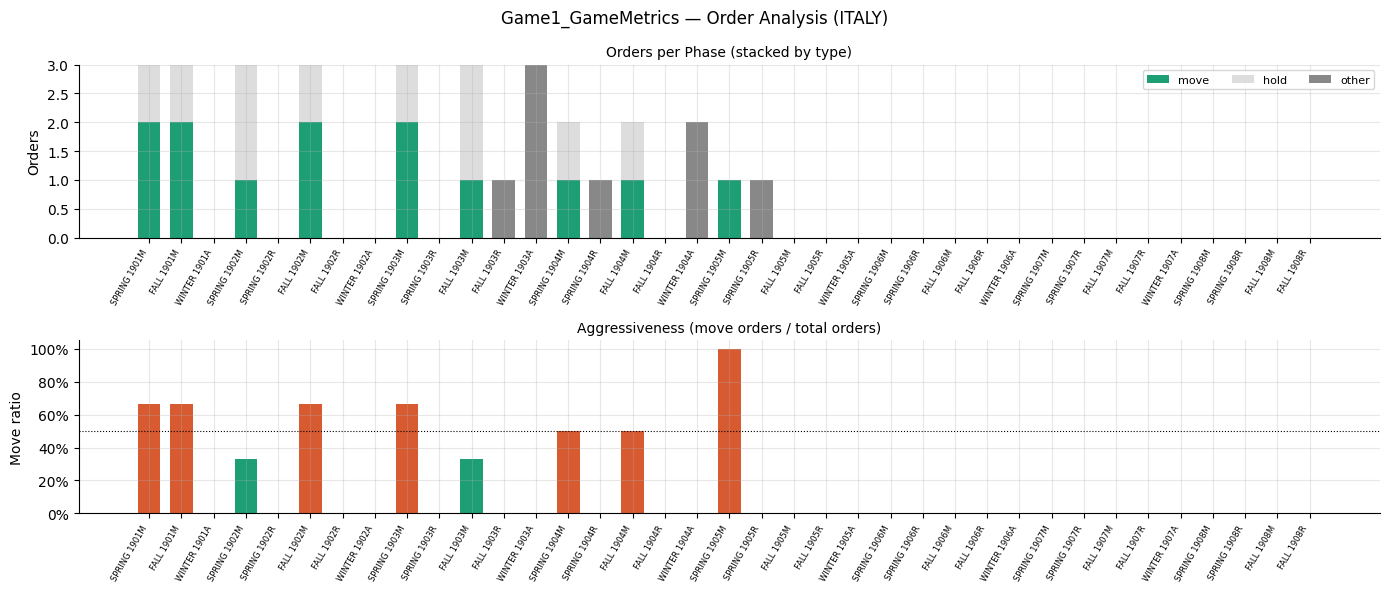

Game1_GameMetrics: 31 orders total — move=13, hold=10, other=8



/tmp/ipykernel_7752/2009156167.py:53: RuntimeWarning: invalid value encountered in divide
  aggr  = np.where(total > 0, moves / total, 0)


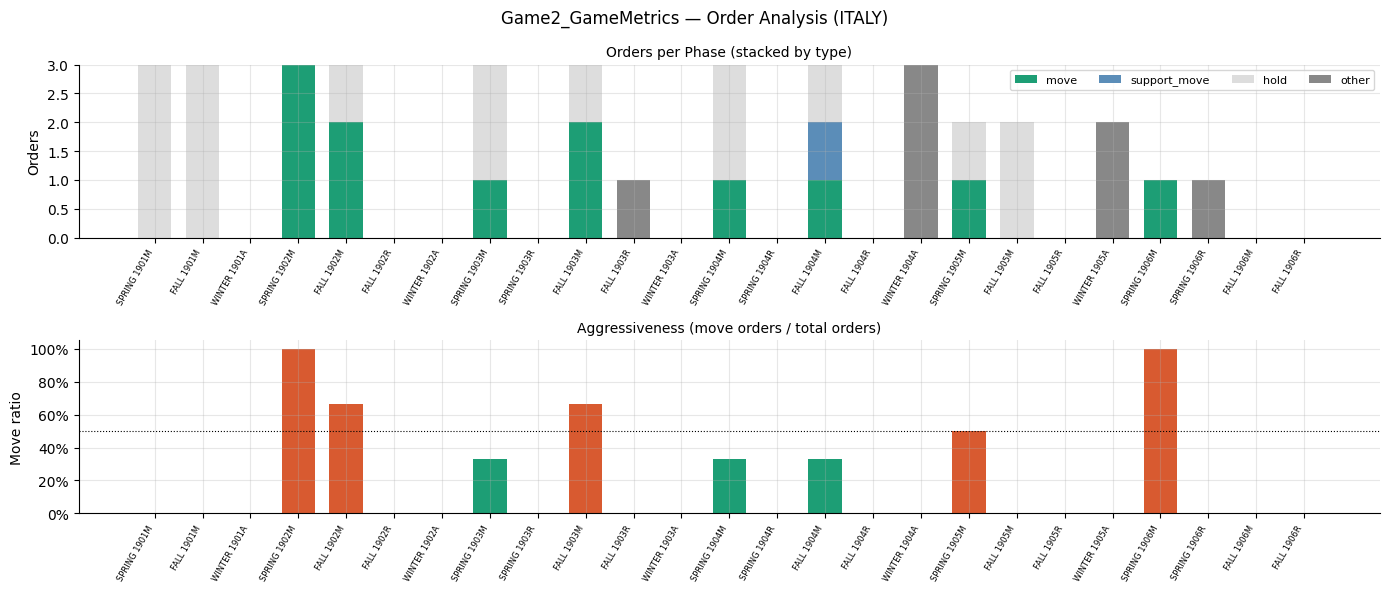

Game2_GameMetrics: 36 orders total — move=12, support_move=1, hold=16, other=7



/tmp/ipykernel_7752/2009156167.py:53: RuntimeWarning: invalid value encountered in divide
  aggr  = np.where(total > 0, moves / total, 0)


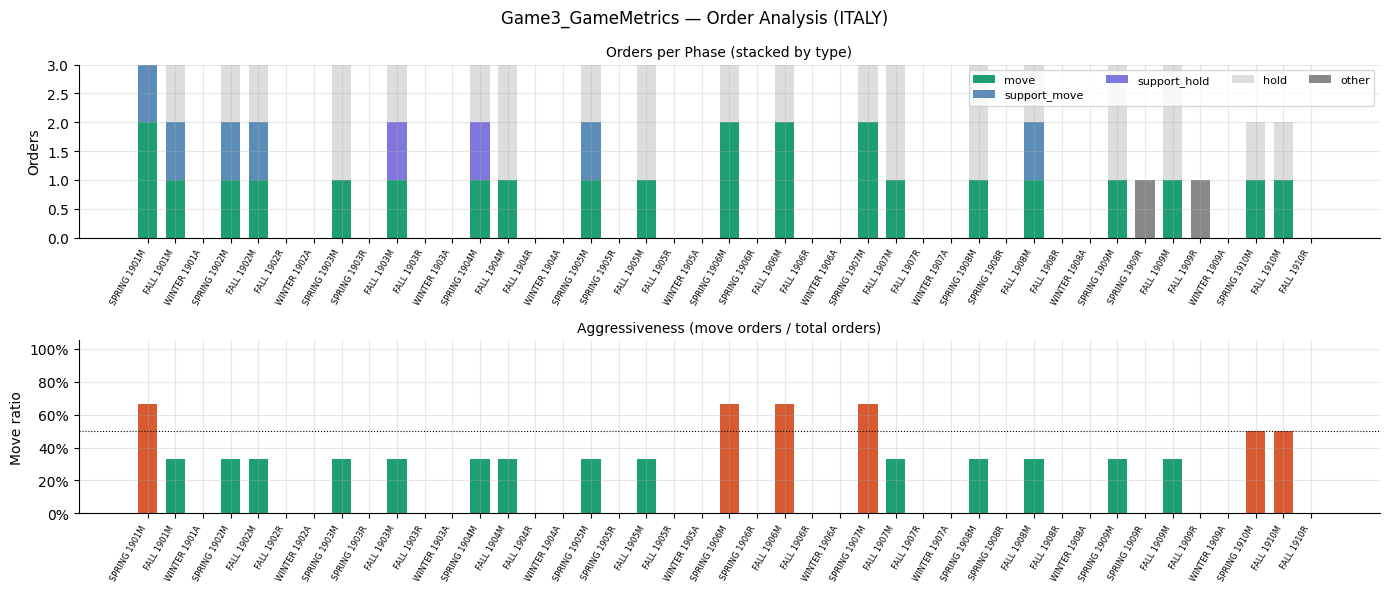

Game3_GameMetrics: 60 orders total — move=24, support_move=6, support_hold=2, hold=26, other=2



In [5]:
# ── Order Analysis ────────────────────────────────────────────────────────────
ORDER_COLORS = {
    'move':         '#1D9E75',
    'support_move': '#5B8DB8',
    'support_hold': '#7F77DD',
    'hold':         '#DDDDDD',
    'convoy':       '#F4A261',
    'build':        '#2A9D8F',
    'disband':      '#D85A30',
    'other':        '#888888',
}

for name, events in all_games:
    ord_events = sorted(
        [e for e in events if e['event'] == 'orders_submitted' and e.get('power') == AGENT_POWER],
        key=lambda e: phase_key(e['phase'])
    )
    if not ord_events:
        print(f'{name}: no orders from {AGENT_POWER}'); continue

    rows = []
    for e in ord_events:
        types = [classify_order(o) for o in e['orders']] if e['orders'] else []
        cnt = defaultdict(int)
        for t in types: cnt[t] += 1
        rows.append({'phase': e['phase'], 'total': len(types), **cnt})
    df = pd.DataFrame(rows).fillna(0)

    phases  = df['phase'].tolist()
    xlabels = [p.replace(' MOVEMENT','M').replace(' RETREATS','R')
                .replace(' ADJUSTMENTS','A') for p in phases]
    x = range(len(phases))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
    fig.suptitle(f'{name} — Order Analysis ({AGENT_POWER})', fontsize=12)

    # Stacked bar per phase
    bottom = np.zeros(len(phases))
    for otype, color in ORDER_COLORS.items():
        vals = df.get(otype, pd.Series(0, index=df.index)).values
        if vals.sum() == 0: continue
        ax1.bar(x, vals, bottom=bottom, color=color, label=otype, width=0.7)
        bottom += vals
    ax1.set_xticks(x)
    ax1.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=6)
    ax1.set_ylabel('Orders')
    ax1.set_title('Orders per Phase (stacked by type)', fontsize=10)
    ax1.legend(fontsize=8, ncol=4)

    # Aggressiveness = moves / total (higher = more aggressive)
    moves = df.get('move', pd.Series(0, index=df.index)).values
    total = df['total'].values
    aggr  = np.where(total > 0, moves / total, 0)
    bar_colors = ['#D85A30' if a >= 0.5 else '#1D9E75' for a in aggr]
    ax2.bar(x, aggr, color=bar_colors, width=0.7)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_xticks(x)
    ax2.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=6)
    ax2.set_ylabel('Move ratio')
    ax2.set_ylim(0, 1.05)
    ax2.set_title('Aggressiveness (move orders / total orders)', fontsize=10)
    ax2.axhline(0.5, color='black', linewidth=0.8, linestyle=':')

    plt.tight_layout()
    plt.show()

    total_orders = int(df['total'].sum())
    type_totals = {t: int(df.get(t, pd.Series(0)).sum()) for t in ORDER_COLORS if t in df.columns}
    print(f"{name}: {total_orders} orders total — " +
          ", ".join(f"{t}={n}" for t, n in type_totals.items() if n > 0))
    print()


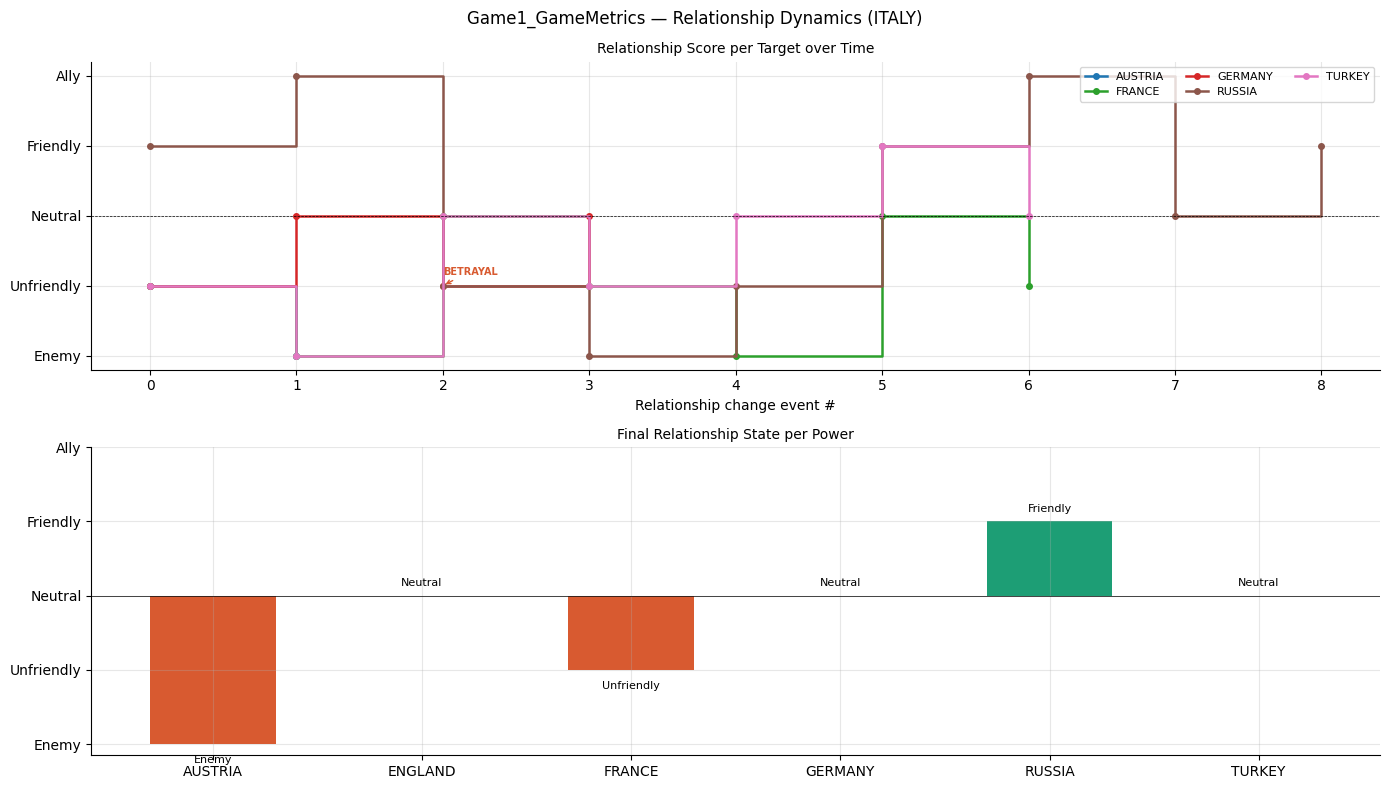

Game1_GameMetrics: 29 relationship changes
  Flagged betrayals (betrayal=True)  : 1
    FALL 1903 RETREATS: ITALY vs RUSSIA  Ally → Unfriendly  (trigger: negotiation_diary)
  Large drops (≥2 levels downward)   : 2
    FALL 1906 MOVEMENT: vs RUSSIA  Ally → Neutral



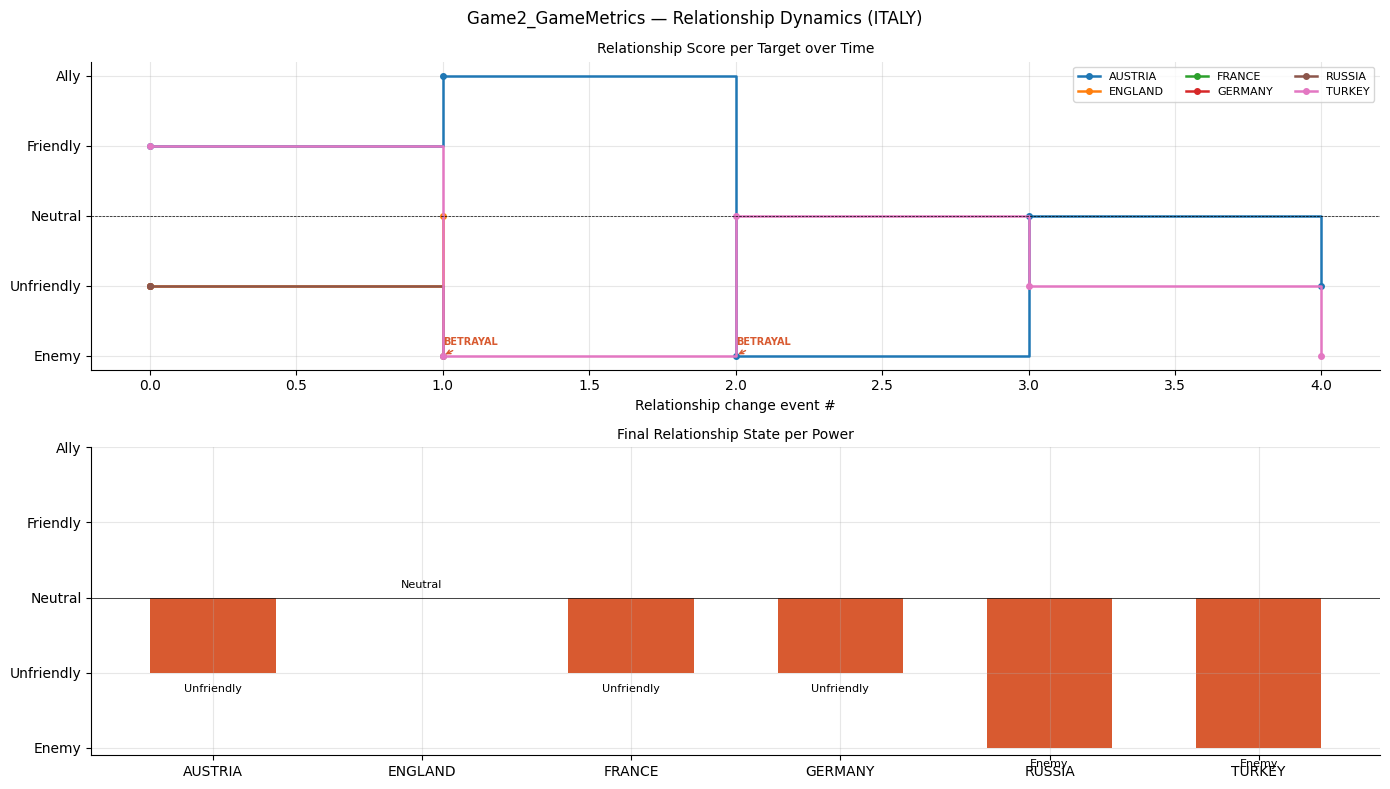

Game2_GameMetrics: 16 relationship changes
  Flagged betrayals (betrayal=True)  : 2
    FALL 1901 MOVEMENT: ITALY vs TURKEY  Friendly → Enemy  (trigger: state_update)
    SPRING 1903 RETREATS: ITALY vs AUSTRIA  Ally → Enemy  (trigger: state_update)
  Large drops (≥2 levels downward)   : 2



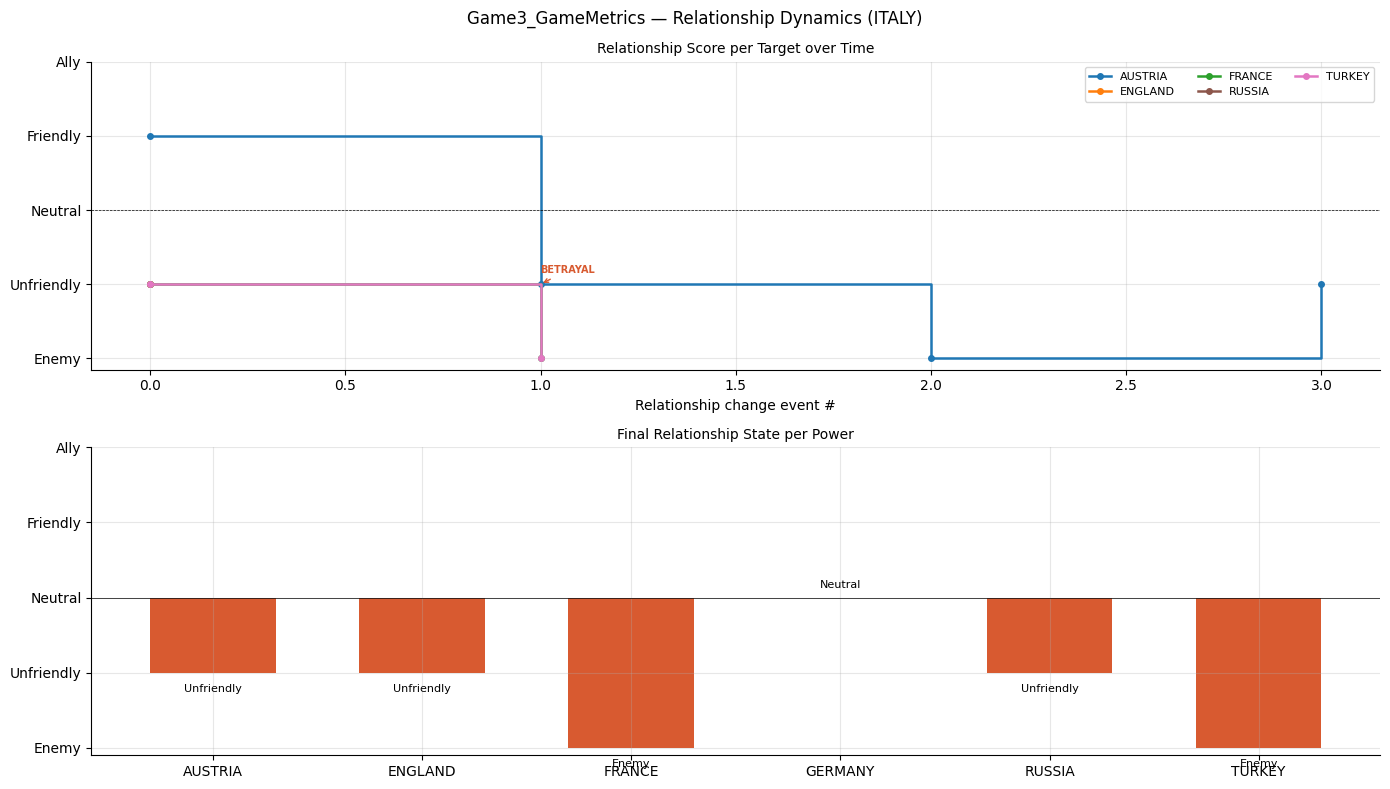

Game3_GameMetrics: 10 relationship changes
  Flagged betrayals (betrayal=True)  : 1
    SPRING 1906 RETREATS: ITALY vs AUSTRIA  Friendly → Unfriendly  (trigger: state_update)
  Large drops (≥2 levels downward)   : 1



In [6]:
# ── Relationship Dynamics & Betrayals ─────────────────────────────────────────
for name, events in all_games:
    rel_events = sorted(
        [e for e in events if e['event'] == 'relationship_change'
         and e.get('power') == AGENT_POWER],
        key=lambda e: (phase_key(e['phase']), e['ts'])
    )
    if not rel_events:
        print(f'{name}: no relationship data'); continue

    # Reconstruct relationship score per target over all phases
    sc_events = sorted(
        [e for e in events if e['event'] == 'sc_snapshot'],
        key=lambda e: phase_key(e['phase'])
    )
    all_phases = [e['phase'] for e in sc_events]

    all_powers_in_game = [p for p in ALL_POWERS if p != AGENT_POWER]
    tgt_scores = {t: [] for t in all_powers_in_game}
    tgt_phases = {t: [] for t in all_powers_in_game}

    state = {t: 0 for t in all_powers_in_game}
    for e in rel_events:
        tgt = e.get('target')
        if tgt not in all_powers_in_game: continue
        state[tgt] = REL_SCORE.get(e['new'], 0)
        tgt_scores[tgt].append(state[tgt])
        tgt_phases[tgt].append(e['phase'])

    betrayals = [e for e in rel_events if e.get('betrayal')]
    perceived_betrayals = [e for e in rel_events
                           if REL_SCORE.get(e.get('new'), 0) - REL_SCORE.get(e.get('old'), 0) <= -2]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'{name} — Relationship Dynamics ({AGENT_POWER})', fontsize=12)

    # Relationship score over events
    for tgt in all_powers_in_game:
        if not tgt_scores[tgt]: continue
        xs = list(range(len(tgt_phases[tgt])))
        ax1.step(xs, tgt_scores[tgt], where='post',
                 color=POWER_COLORS[tgt], linewidth=1.8, label=tgt, marker='o', markersize=4)
        # Annotate betrayals
        for e in betrayals:
            if e['target'] == tgt:
                idx = tgt_phases[tgt].index(e['phase']) if e['phase'] in tgt_phases[tgt] else None
                if idx is not None:
                    ax1.annotate('BETRAYAL', (idx, tgt_scores[tgt][idx]),
                                 textcoords='offset points', xytext=(0, 8),
                                 fontsize=7, color='#D85A30', fontweight='bold',
                                 arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1))
    ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax1.set_yticks([-2, -1, 0, 1, 2])
    ax1.set_yticklabels(['Enemy', 'Unfriendly', 'Neutral', 'Friendly', 'Ally'])
    ax1.set_xlabel('Relationship change event #')
    ax1.set_title('Relationship Score per Target over Time', fontsize=10)
    ax1.legend(fontsize=8, ncol=3)

    # Relationship heatmap: final state per target
    targets = all_powers_in_game
    final_scores = [state[t] for t in targets]
    colors = ['#D85A30' if s < 0 else '#1D9E75' if s > 0 else '#DDDDDD' for s in final_scores]
    bars = ax2.bar(range(len(targets)), final_scores, color=colors, width=0.6)
    ax2.set_xticks(range(len(targets)))
    ax2.set_xticklabels(targets, fontsize=10)
    ax2.set_yticks([-2, -1, 0, 1, 2])
    ax2.set_yticklabels(['Enemy', 'Unfriendly', 'Neutral', 'Friendly', 'Ally'])
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_title('Final Relationship State per Power', fontsize=10)
    for bar, score in zip(bars, final_scores):
        label = {-2:'Enemy',-1:'Unfriendly',0:'Neutral',1:'Friendly',2:'Ally'}.get(score,'')
        ax2.text(bar.get_x() + bar.get_width()/2, score + (0.1 if score >= 0 else -0.15),
                 label, ha='center', va='bottom' if score >= 0 else 'top', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"{name}: {len(rel_events)} relationship changes")
    print(f"  Flagged betrayals (betrayal=True)  : {len(betrayals)}")
    if betrayals:
        for b in betrayals:
            print(f"    {b['phase']}: {AGENT_POWER} vs {b['target']}  "
                  f"{b['old']} → {b['new']}  (trigger: {b.get('trigger','-')})")
    print(f"  Large drops (≥2 levels downward)   : {len(perceived_betrayals)}")
    if perceived_betrayals:
        for b in perceived_betrayals:
            if not b.get('betrayal'):
                print(f"    {b['phase']}: vs {b['target']}  {b['old']} → {b['new']}")
    print()


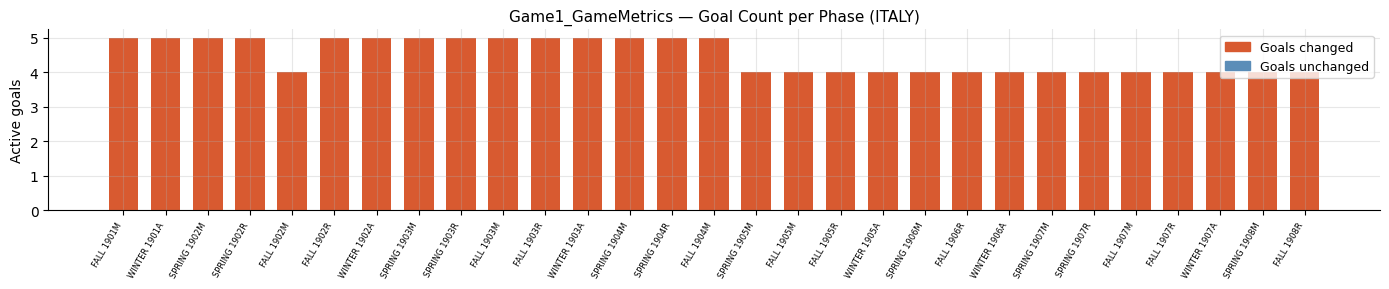

Game1_GameMetrics: goals changed in 29/29 phases (100%), avg 4.5 goals/phase



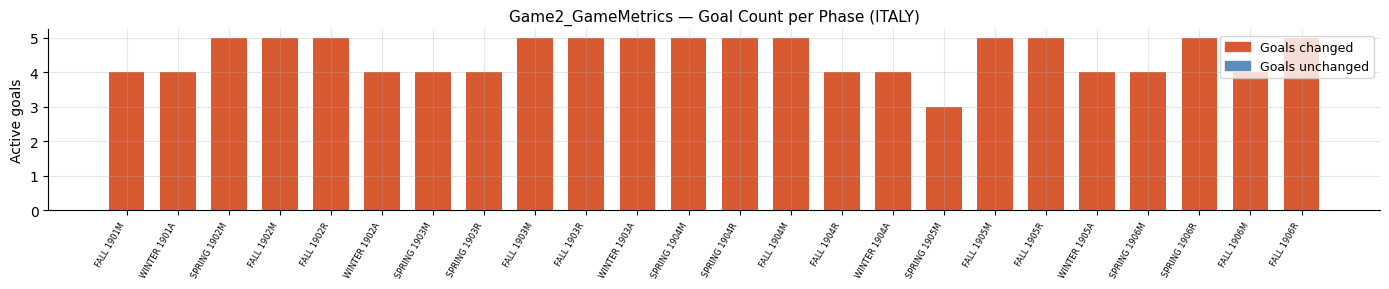

Game2_GameMetrics: goals changed in 24/24 phases (100%), avg 4.5 goals/phase



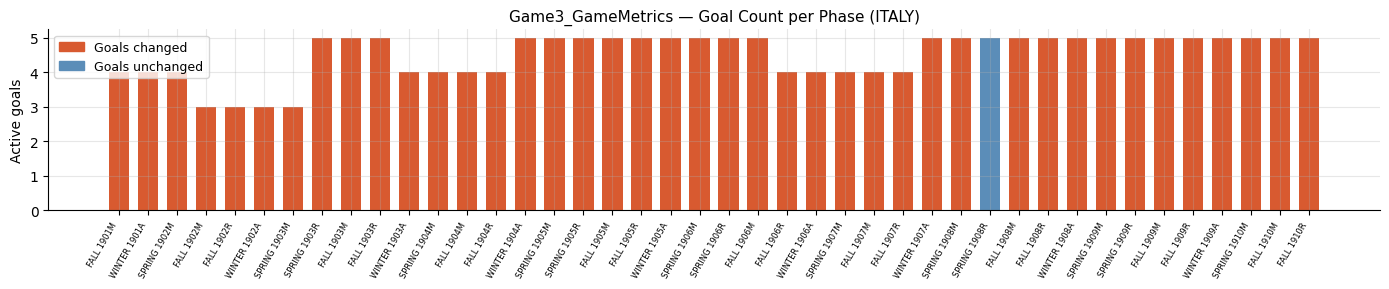

Game3_GameMetrics: goals changed in 41/42 phases (98%), avg 4.5 goals/phase



In [7]:
# ── Goal Volatility ───────────────────────────────────────────────────────────
for name, events in all_games:
    goal_events = sorted(
        [e for e in events if e['event'] == 'goal_update'
         and e.get('power') == AGENT_POWER],
        key=lambda e: phase_key(e['phase'])
    )
    if not goal_events:
        print(f'{name}: no goal data'); continue

    phases  = [e['phase'] for e in goal_events]
    n_goals = [e['n_goals'] for e in goal_events]
    changed = [e.get('changed', False) for e in goal_events]
    xlabels = [p.replace(' MOVEMENT','M').replace(' RETREATS','R')
                .replace(' ADJUSTMENTS','A') for p in phases]

    fig, ax = plt.subplots(figsize=(14, 3))
    bar_colors = ['#D85A30' if c else '#5B8DB8' for c in changed]
    ax.bar(range(len(phases)), n_goals, color=bar_colors, width=0.7)
    ax.set_xticks(range(len(phases)))
    ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=6)
    ax.set_ylabel('Active goals')
    ax.set_title(f'{name} — Goal Count per Phase ({AGENT_POWER})', fontsize=11)
    ax.legend(handles=[mpatches.Patch(color='#D85A30', label='Goals changed'),
                       mpatches.Patch(color='#5B8DB8', label='Goals unchanged')], fontsize=9)
    plt.tight_layout()
    plt.show()

    n_changed = sum(changed)
    change_rate = n_changed / len(goal_events) if goal_events else 0
    print(f"{name}: goals changed in {n_changed}/{len(goal_events)} phases ({change_rate:.0%}), "
          f"avg {np.mean(n_goals):.1f} goals/phase")
    print()


In [8]:
# ── Summary Table ─────────────────────────────────────────────────────────────
rows = []
for name, events in all_games:
    sc_events = sorted([e for e in events if e['event'] == 'sc_snapshot'],
                       key=lambda e: phase_key(e['phase']))
    msgs      = [e for e in events if e['event'] == 'message_sent'
                 and e.get('sender') == AGENT_POWER]
    ords      = [e for e in events if e['event'] == 'orders_submitted'
                 and e.get('power') == AGENT_POWER]
    rels      = [e for e in events if e['event'] == 'relationship_change'
                 and e.get('power') == AGENT_POWER]
    goals     = [e for e in events if e['event'] == 'goal_update'
                 and e.get('power') == AGENT_POWER]

    final_sc  = sc_events[-1]['counts'].get(AGENT_POWER, 0) if sc_events else 0
    won       = final_sc >= WIN_THRESHOLD
    avg_sc    = np.mean([e['counts'].get(AGENT_POWER, 0) for e in sc_events]) if sc_events else 0

    total_msg    = len(msgs)
    avg_msg_len  = np.mean([m['n_chars'] for m in msgs]) if msgs else 0
    total_chars  = sum(m['n_chars'] for m in msgs)

    all_orders   = [o for e in ords for o in (e['orders'] or [])]
    move_cnt     = sum(1 for o in all_orders if classify_order(o) == 'move')
    aggr         = move_cnt / len(all_orders) if all_orders else 0

    betrayals    = sum(1 for e in rels if e.get('betrayal'))
    big_drops    = sum(1 for e in rels
                       if REL_SCORE.get(e.get('new'),0) - REL_SCORE.get(e.get('old'),0) <= -2)
    rel_changes  = len(rels)

    goal_changes = sum(1 for e in goals if e.get('changed'))
    goal_rate    = goal_changes / len(goals) if goals else 0

    rows.append({
        'Game':                name,
        'Outcome':             'WIN' if won else 'loss',
        'Final SCs':           final_sc,
        'Avg SCs':             f'{avg_sc:.1f}',
        'Messages':            total_msg,
        'Avg msg length':      f'{avg_msg_len:.0f}',
        'Total chars':         f'{total_chars:,}',
        'Aggressiveness':      f'{aggr:.0%}',
        'Rel. changes':        rel_changes,
        'Betrayals (flagged)': betrayals,
        'Big drops (≥2)':      big_drops,
        'Goal change rate':    f'{goal_rate:.0%}',
    })

summary_df = pd.DataFrame(rows).set_index('Game')
pd.set_option('display.max_colwidth', 30)
display(summary_df.T)


Game,Game1_GameMetrics,Game2_GameMetrics,Game3_GameMetrics
Outcome,loss,loss,loss
Final SCs,1,1,3
Avg SCs,1.9,2.4,3.0
Messages,708,718,1204
Avg msg length,211,227,209
Total chars,"149,688","162,735","251,127"
Aggressiveness,42%,33%,40%
Rel. changes,29,16,10
Betrayals (flagged),1,2,1
Big drops (≥2),2,2,1
